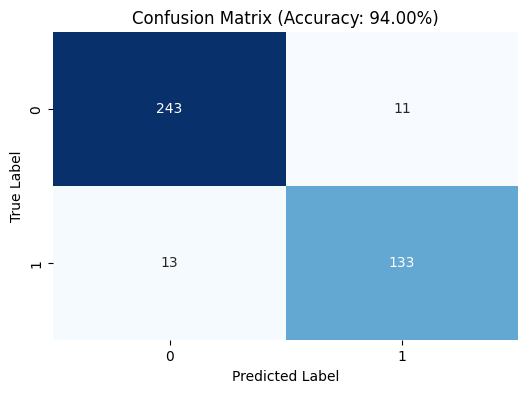

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def generate_realistic_dataset(num_samples=2000):
    np.random.seed(42)

    time_of_day = np.random.randint(0, 24, num_samples)
    light_level = np.random.randint(0, 100, num_samples)
    motion_detected = np.random.randint(0, 2, num_samples)

    lights_on = []
    for t, l, m in zip(time_of_day, light_level, motion_detected):
        if t >= 18 or t < 6:
            if l < 30 or m == 1:
                lights_on.append(1)
            else:
                lights_on.append(0)
        else:
            if l < 10 and m == 1:
                lights_on.append(1)
            else:
                lights_on.append(0)

    data = {
        'time_of_day': time_of_day,
        'light_level': light_level,
        'motion_detected': motion_detected,
        'lights_on': lights_on
    }
    return pd.DataFrame(data)

realistic_df = generate_realistic_dataset(num_samples=2000)
realistic_df.to_csv("realistic_time_light_motion_data.csv", index=False)


df = pd.read_csv("realistic_time_light_motion_data.csv")

# Feature engineering
df['light_level'] = df['light_level'] / 100
df['time_of_day'] = df['time_of_day'] / 24
df['time_of_day_sin'] = np.sin(2 * np.pi * df['time_of_day'])
df['time_of_day_cos'] = np.cos(2 * np.pi * df['time_of_day'])
df['light_motion_interaction'] = df['light_level'] * df['motion_detected']
df['light_level_squared'] = df['light_level'] ** 2

X = df[['time_of_day', 'light_level', 'motion_detected', 'time_of_day_sin',
        'time_of_day_cos', 'light_motion_interaction', 'light_level_squared']]
y = df['lights_on']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f'Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
